# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/varshitha922/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The dataset contains 30,000 rows and 44 columns. The distributions show that search volume, impressions, clicks, and sessions have heavy right tails. Their skewness values are 26.02, 11.38, 18.35, and 12.13 respectively. Their maximum values are much higher than their median values, showing that a small number of pages have very large values. Content age has a lower skewness of 0.49, while days since last update has a skewness of 1.16. Therefore, traffic-related fields show stronger heavy tails than content age and update age.




Dataset shape: (30000, 44)

Distribution summary:
       search_volume  impressions_90d  clicks_90d  sessions_90d  \
count       27532.00         30000.00    30000.00      30000.00   
mean          158.88          5200.37       16.10         37.07   
std          1518.27         16838.02       75.08        107.07   
min             0.00             1.00        0.00          1.00   
25%             0.00            81.00        0.00          2.00   
50%            10.00           731.00        1.00          7.00   
75%            20.00          3615.25        7.00         27.00   
max         74000.00        517715.00     4178.00       4345.00   

       content_age_days  days_since_last_update  
count          30000.00                30000.00  
mean             256.17                   46.10  
std              132.71                   42.08  
min               90.00                    1.00  
25%              132.00                   20.00  
50%              236.00                   20.0

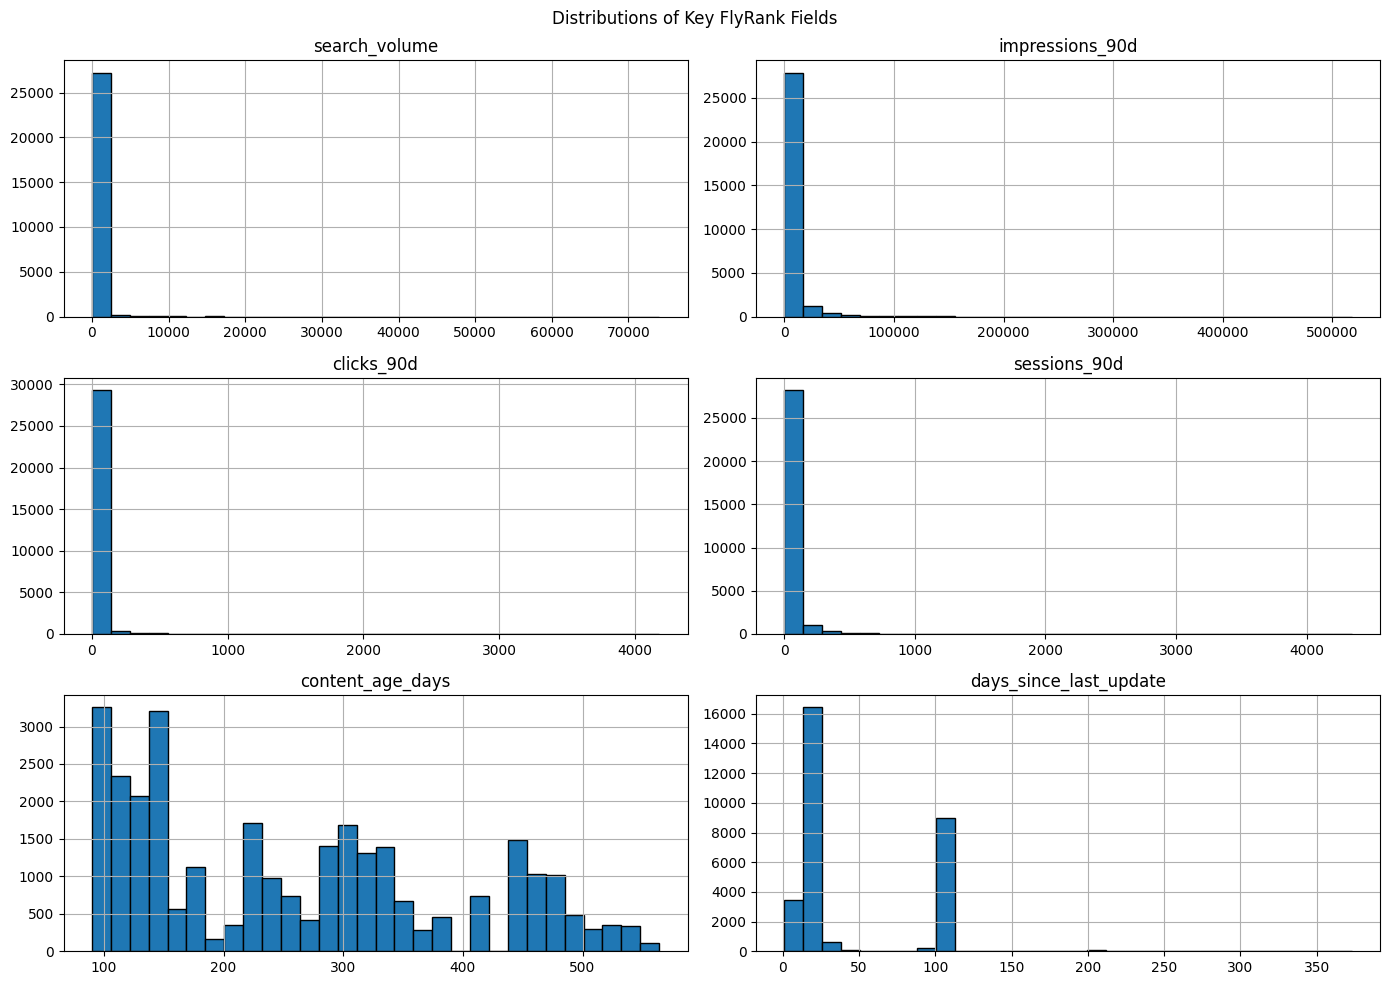

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt

# Load the FlyRank starter dataset
url = "https://raw.githubusercontent.com/varshitha922/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

# Select important numeric fields
fields = [
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update"
]

# Check that the required fields exist
available_fields = [col for col in fields if col in df.columns]
print("Dataset shape:", df.shape)
print("\nDistribution summary:")
print(df[available_fields].describe().round(2))

# Check skewness to identify heavy tails
print("\nSkewness:")
print(df[available_fields].skew().round(2))

# Plot distributions
df[available_fields].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Distributions of Key FlyRank Fields")
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal test #1 — Search volume

**Verdict: MIXED.** The middle search-volume group had the highest median impressions (1,006.5; n = 2,290). The highest search-volume group had a lower median (842.5; n = 6,850), so impressions did not increase consistently with search volume. The lowest group had a median of 929.0 (n = 18,392).

### Signal test #2 — Content age

**Verdict: MIXED.** The median impressions varied across the age groups: 768.0, 796.5, 601.0, and 733.0. There was no consistent increase or decrease as content age increased.

### Signal test #3 — Time since last update

**Verdict: MIXED.** The group with 20–104 days since its last update had the highest median impressions (1,262; n = 13,816). The group with more than 104 days had the lowest median (30; n = 318), while the group with up to 20 days had a median of 363 (n = 15,866). The pattern was not consistently increasing or decreasing.


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

# Use the dataset loaded in Section 1.
# If df is not available, load it again.
if "df" not in globals():
    url = "https://raw.githubusercontent.com/varshitha922/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
    df = pd.read_csv(url)

def signal_test(column, title):
    print("\n" + title)
    print("Claim: pages with different", column, "levels may have different impressions.")

    temp = df[[column, "impressions_90d"]].dropna().copy()
    temp["group"] = pd.qcut(temp[column], q=4, duplicates="drop")

    result = (
        temp.groupby("group", observed=True)
        .agg(
            n=("impressions_90d", "size"),
            median_impressions=("impressions_90d", "median")
        )
        .reset_index()
    )

    print(result.to_string(index=False))
    print("Check: each group should have at least 50 rows.")

# Test 1: Search volume
signal_test("search_volume", "SIGNAL TEST 1 — Search volume")

# Test 2: Content age
signal_test("content_age_days", "SIGNAL TEST 2 — Content age")

# Test 3: Days since last update
signal_test("days_since_last_update", "SIGNAL TEST 3 — Time since last update")


SIGNAL TEST 1 — Search volume
Claim: pages with different search_volume levels may have different impressions.
          group     n  median_impressions
 (-0.001, 10.0] 18392               929.0
   (10.0, 20.0]  2290              1006.5
(20.0, 74000.0]  6850               842.5
Check: each group should have at least 50 rows.

SIGNAL TEST 2 — Content age
Claim: pages with different content_age_days levels may have different impressions.
          group    n  median_impressions
(89.999, 132.0] 7518               768.0
 (132.0, 236.0] 8128               796.5
 (236.0, 333.0] 6917               601.0
 (333.0, 564.0] 7437               733.0
Check: each group should have at least 50 rows.

SIGNAL TEST 3 — Time since last update
Claim: pages with different days_since_last_update levels may have different impressions.
         group     n  median_impressions
 (0.999, 20.0] 15866               363.0
 (20.0, 104.0] 13816              1262.0
(104.0, 373.0]   318                30.0
Check: each 

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### Section 3 — The flag-linked test

**Signal tested:** `stale_visible_page`

**Verdict: MIXED.** The rule identifies pages that have not been updated for at least 180 days and have at least 500 impressions. Out of 174 stale pages, only 17 pages (9.77%) met the visibility threshold. The median impressions for stale pages was 15.5, compared with 742 for pages updated within 180 days. This shows that most stale pages do not have high visibility. The rule can help identify a small group of stale pages for review, but the data does not support using staleness alone as a sign of high visibility.


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 3 — Test the stale_visible_page flag assumption

# Recreate the documented rule using the available data.
# A page is flagged if it was not updated for 180+ days
# and received at least 500 impressions.

required = ["days_since_last_update", "impressions_90d"]
test_df = df[required].dropna().copy()

test_df["stale"] = test_df["days_since_last_update"] >= 180
test_df["visible"] = test_df["impressions_90d"] >= 500
test_df["stale_visible_flag"] = test_df["stale"] & test_df["visible"]

print("Total usable rows:", len(test_df))
print("\nFlag count:")
print(test_df["stale_visible_flag"].value_counts().rename(index={True: "Flagged", False: "Not flagged"}))

print("\nComparison: stale vs not stale")
comparison = (
    test_df.groupby("stale")
    .agg(
        n=("impressions_90d", "size"),
        median_impressions=("impressions_90d", "median"),
        pages_with_500_plus_impressions=("visible", "sum")
    )
    .rename(index={True: "Stale (180+ days)", False: "Updated within 180 days"})
)

print(comparison.to_string())

print("\nAmong stale pages, percentage with 500+ impressions:")
stale_rows = test_df[test_df["stale"]]
if len(stale_rows) > 0:
    print(round(100 * stale_rows["visible"].mean(), 2), "%")
else:
    print("No stale pages found.")

Total usable rows: 30000

Flag count:
stale_visible_flag
Not flagged    29983
Flagged           17
Name: count, dtype: int64

Comparison: stale vs not stale
                             n  median_impressions  pages_with_500_plus_impressions
stale                                                                              
Updated within 180 days  29826               742.0                            16709
Stale (180+ days)          174                15.5                               17

Among stale pages, percentage with 500+ impressions:
9.77 %


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

# Section 4 — Practical takeaway

The content team should not prioritize pages based only on how long ago they were updated. Only 17 out of 174 stale pages (9.77%) met the 500-impression visibility threshold. The stale-and-visible rule can help create a small review list, but the team should also consider other content performance signals.


In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 4 — Practical takeaway

print("The content team should not prioritize pages based only on how long ago they were updated.")
print("Only 17 out of 174 stale pages (9.77%) met the 500-impression visibility threshold.")
print("The stale-and-visible rule can help create a small review list, but the team should also consider other content performance signals.")

The content team should not prioritize pages based only on how long ago they were updated.
Only 17 out of 174 stale pages (9.77%) met the 500-impression visibility threshold.
The stale-and-visible rule can help create a small review list, but the team should also consider other content performance signals.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.